# 15 - Deep Clustering (Autoencoder and DEC)

**Problem framing.** When cluster structure is tangled non-linearly across many dimensions and buried in noise, clustering the raw features struggles and a *linear* projection (PCA) cannot undo the tangle. Representation learning offers a non-linear alternative: an autoencoder learns a compact embedding, and Deep Embedded Clustering (DEC) then fine-tunes that embedding with a clustering objective.

**This notebook uses the optional PyTorch extra** (`poetry install --with deep`); the rest of the lab needs no deep-learning dependency.

**Assumptions.** There is genuine non-linear structure for a network to exploit; the data is scaled; and the number of clusters is known.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler

sys.path.append(str(Path.cwd() / "src"))

from unsup_lab.deep import deep_cluster, deep_embedded_clustering

## A non-linearly tangled, noisy dataset

Four Gaussian blobs in a 5D latent space are pushed through a fixed non-linear map into 25 dimensions, then 40 pure-noise dimensions are appended. The cluster identity is fully determined by the latent blobs, but it is hidden behind the non-linear tangle and the noise.

In [2]:
rng = np.random.default_rng(0)
centres = rng.normal(scale=2.2, size=(4, 5))
latent = np.vstack([c + rng.normal(scale=0.6, size=(70, 5)) for c in centres])
truth = np.repeat(range(4), 70)

w1 = rng.normal(size=(5, 20))
w2 = rng.normal(size=(20, 25))
tangled = np.tanh(latent @ w1) @ w2 + rng.normal(scale=0.2, size=(280, 25))
noise = rng.normal(scale=1.0, size=(280, 40))
features = StandardScaler().fit_transform(np.hstack([tangled, noise]))
features.shape

(280, 65)

## Classical baselines

KMeans on the raw 65 dimensions, and KMeans on a 10-component PCA projection. PCA is linear, so it cannot unpick the non-linear tangle.

In [3]:
raw_labels = KMeans(n_clusters=4, n_init=10, random_state=0).fit_predict(features)
pca_features = PCA(n_components=10, random_state=0).fit_transform(features)
pca_labels = KMeans(n_clusters=4, n_init=10, random_state=0).fit_predict(pca_features)

print(f"raw KMeans ARI: {adjusted_rand_score(truth, raw_labels):.3f}")
print(f"PCA KMeans ARI: {adjusted_rand_score(truth, pca_labels):.3f}")

raw KMeans ARI: 0.865
PCA KMeans ARI: 0.858


## Autoencoder embedding + KMeans

A plain autoencoder learns a non-linear 10D embedding by reconstruction, and we cluster that. Note the honest result below: a reconstruction autoencoder is **not** a free lunch - it optimises for reproducing the input (noise included), not for separating clusters, so it only matches the raw baseline here.

In [4]:
ae = deep_cluster(
    features, n_clusters=4, latent_dim=10, hidden_dim=64, epochs=200, random_state=0
)
print(f"autoencoder + KMeans ARI: {adjusted_rand_score(truth, ae.labels):.3f}")

autoencoder + KMeans ARI: 0.869


## Deep Embedded Clustering (DEC)

DEC starts from the pretrained autoencoder, initialises cluster centres with KMeans, then fine-tunes the encoder *and* the centres to sharpen a soft assignment (Student-t kernel) towards a confident target distribution. The clustering objective is what makes the difference.

In [5]:
dec = deep_embedded_clustering(
    features, n_clusters=4, latent_dim=10, hidden_dim=64,
    pretrain_epochs=200, cluster_epochs=80, random_state=0,
)
print(f"DEC ARI: {adjusted_rand_score(truth, dec.labels):.3f}")

DEC ARI: 0.928


In [6]:
results = pd.DataFrame(
    [
        {"method": "raw KMeans", "ARI": adjusted_rand_score(truth, raw_labels)},
        {"method": "PCA + KMeans", "ARI": adjusted_rand_score(truth, pca_labels)},
        {"method": "autoencoder + KMeans", "ARI": adjusted_rand_score(truth, ae.labels)},
        {"method": "DEC", "ARI": adjusted_rand_score(truth, dec.labels)},
    ]
).round(3)
results

,method,ARI
0,raw KMeans,0.865
1,PCA + KMeans,0.858
2,autoencoder + KMeans,0.869
3,DEC,0.928


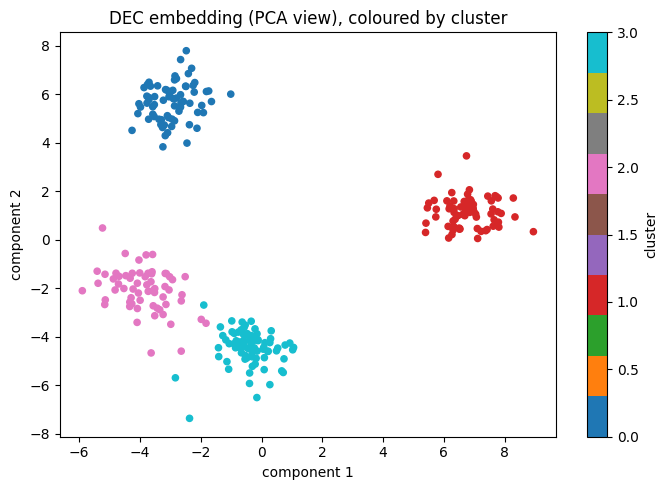

In [7]:
coords = PCA(n_components=2, random_state=0).fit_transform(dec.embedding)
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=dec.labels, cmap="tab10", s=20)
ax.set_title("DEC embedding (PCA view), coloured by cluster")
ax.set_xlabel("component 1")
ax.set_ylabel("component 2")
fig.colorbar(scatter, label="cluster")
plt.tight_layout()
plt.show()

## Interpretation and limitations

On this tangled, noisy data PCA is hurt by its linearity and a plain autoencoder merely matches the raw baseline - because reconstruction is the wrong objective for clustering. DEC, which adds an explicit clustering objective on top of the learned embedding, is the only method that separates the clusters clearly.

**Limitations.**

- Deep clustering is not a default choice: on well-separated or low-dimensional data, KMeans/GMM are simpler and just as good. The win appears with genuine non-linear, high-dimensional structure.
- DEC has more knobs (architecture, latent dimension, learning rate, epochs) and can converge to degenerate or empty clusters; it needs a good autoencoder initialisation.
- Results depend on the random seed more than the classical methods do; report stability, do not cherry-pick a seed.
- The autoencoder still spends capacity reconstructing noise; heavy noise or tiny datasets undermine the whole approach.